# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: XX     |  |
| :-------------|:-------------|
| Thijmen Haverkorn van Rijsewijk | 6500897 |

In [ ]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Thijmen']

## Opdracht 1: Planning.

| Planning Groep: XX     |Tijdstip / Tijdspanne  |
|---|---|
| afronden van de kalibratie | 12:00 |
| uitvoeren van de laatste testmeting | 13:00 |

## Opdracht 2: Import libs.

In [3]:
!pip install pandas

   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.7 MB 4.8 MB/s eta 0:00:02
   ----- ---------------------------------- 1.3/9.7 MB 4.2 MB/s eta 0:00:03
   -------- ------------------------------- 2.1/9.7 MB 4.0 MB/s eta 0:00:02
   ------------ --------------------------- 3.1/9.7 MB 4.0 MB/s eta 0:00:02
   ----------------- ---------------------- 4.2/9.7 MB 4.2 MB/s eta 0:00:02
   -------------------- ------------------- 5.0/9.7 MB 4.0 MB/s eta 0:00:02
   ---------------------- ----------------- 5.5/9.7 MB 3.9 MB/s eta 0:00:02
   ------------------------- -------------- 6.3/9.7 MB 3.8 MB/s eta 0:00:01
   --------------------------- ------------ 6.8/9.7 MB 3.7 MB/s eta 0:00:01
   ------------------------------ --------- 7.3/9.7 MB 3.6 MB/s eta 0:00:01
   -------------------------------- ------- 7.9/9.7 MB 3.4 MB/s eta 0:00:01
   ----------------------------------- ---- 8.7/9.7 MB 3.4 MB/s eta 0:00:01
   ----------------


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [65]
<img src="opstelling calibratie.jpg" width="400">

In deze stap hebben we de ultrasone sensor gekalibreerd om de pulsduur (in microseconden) om te zetten naar een afstand (in centimeters). We hebben hiervoor zowel directe metingen gedaan als een meting met een reflecterend oppervlak om de totale afgelegde afstand ($R$) te bepalen.


In [3]:
import numpy as np

afstanden = np.array([15, 25, 40, 60]) 
tijden = np.array([460, 780, 1210, 1780]) 

alpha, beta = np.polyfit(tijden, afstanden, 1)

print(f"Gevonden alpha: {alpha:.5f}")
print(f"Gevonden beta: {beta:.5f}")

Gevonden alpha: 0.03426
Gevonden beta: -1.22999


## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr    yr     R
0   0   4  10  12.2  55.0
1   0   4  20  12.2  43.0
2   0   4  15  12.2  50.0
3   0   4  10  25.0  62.0
4   0   4  10  30.0  71.0
5   0   4  10  10.0  52.0
6   0   4   0  12.2  61.0


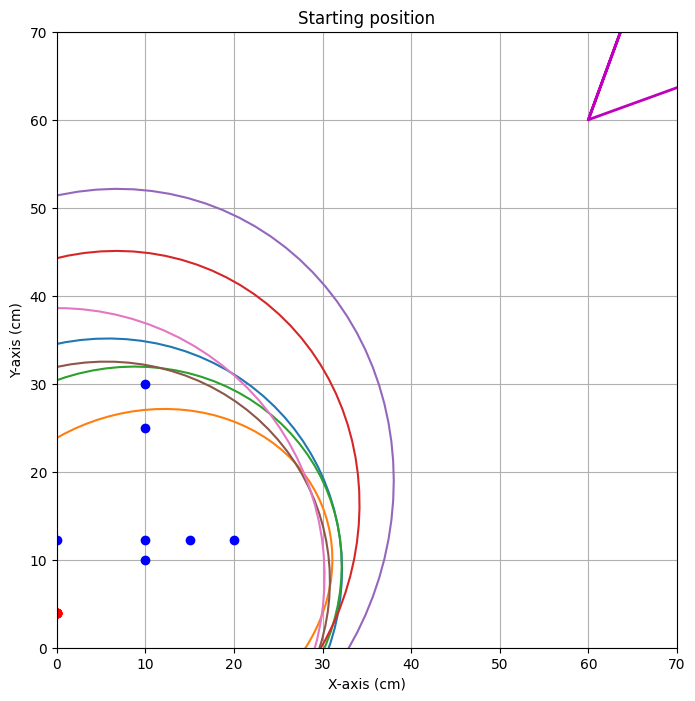


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=99.416


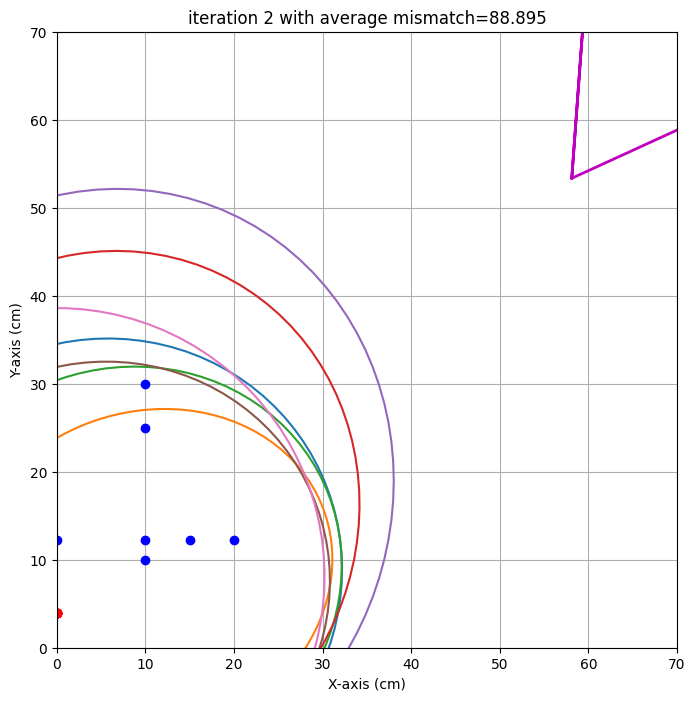

end iteration 2 with average mismatch=88.895


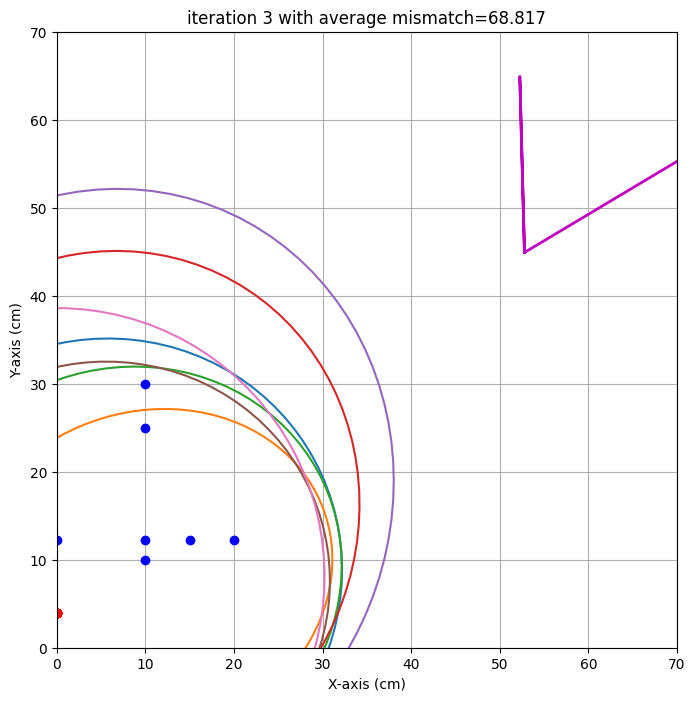

end iteration 3 with average mismatch=68.817


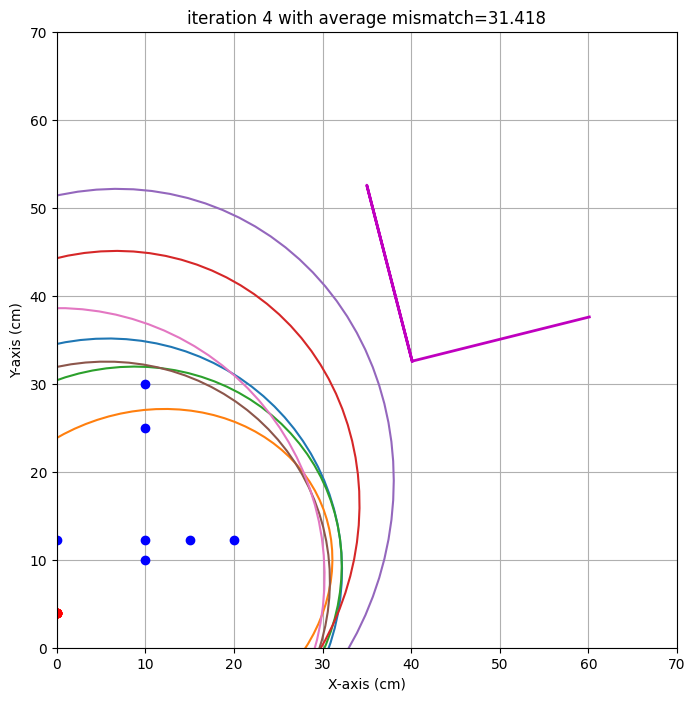

end iteration 4 with average mismatch=31.418


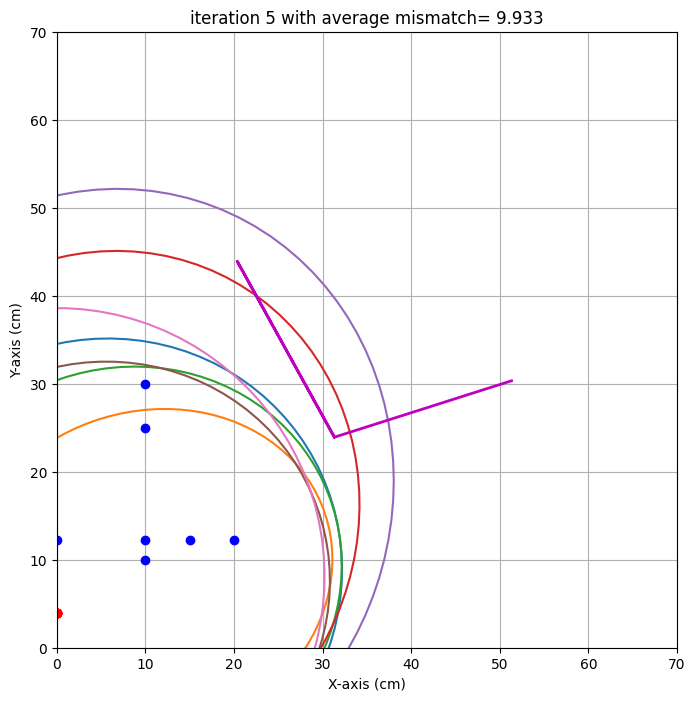

end iteration 5 with average mismatch= 9.933


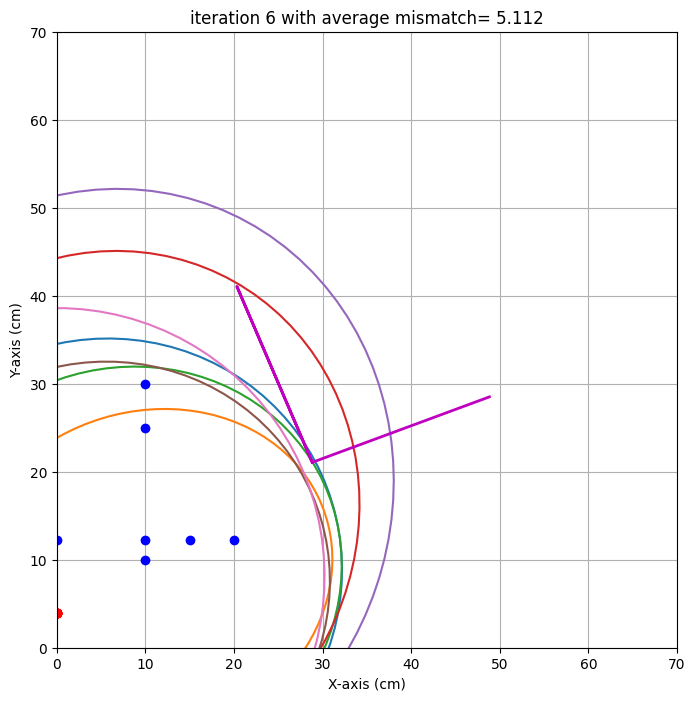

end iteration 6 with average mismatch= 5.112
end iteration 7 with average mismatch= 5.053


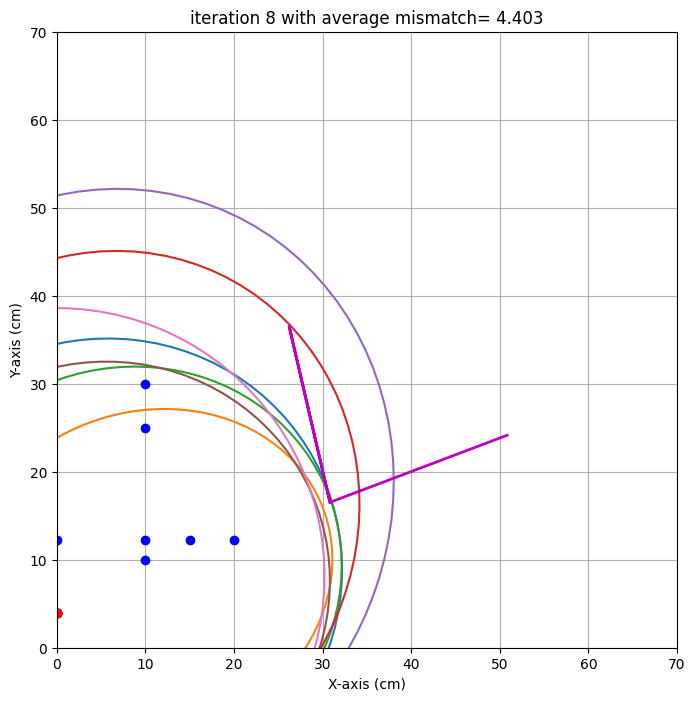

end iteration 8 with average mismatch= 4.403
end iteration 9 with average mismatch= 4.306


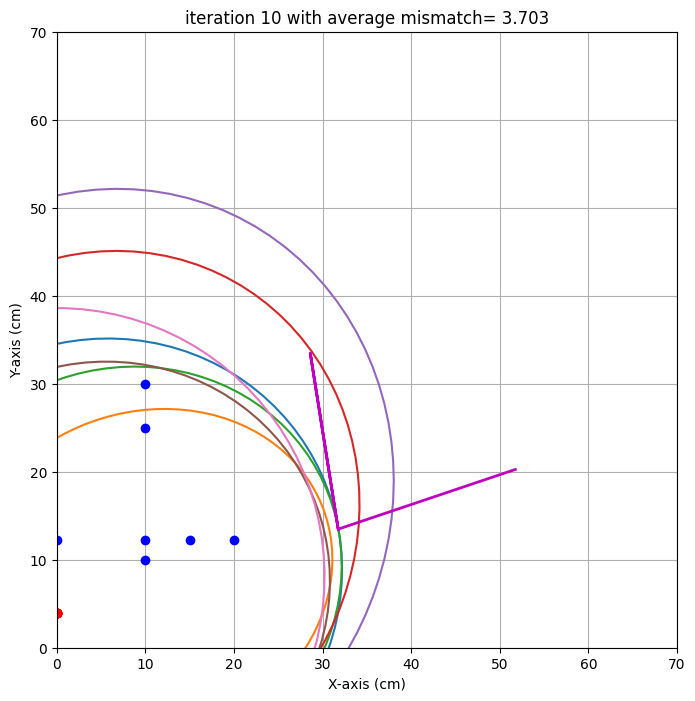

end iteration 10 with average mismatch= 3.703
end iteration 11 with average mismatch= 3.687
end iteration 12 with average mismatch= 3.619
end iteration 13 with average mismatch= 3.567
end iteration 14 with average mismatch= 3.567
end iteration 15 with average mismatch= 3.307
end iteration 16 with average mismatch= 3.077
end iteration 17 with average mismatch= 2.820
end iteration 18 with average mismatch= 2.820
end iteration 19 with average mismatch= 2.815
end iteration 20 with average mismatch= 2.730
end iteration 21 with average mismatch= 2.636
end iteration 22 with average mismatch= 2.537
end iteration 23 with average mismatch= 2.493
end iteration 24 with average mismatch= 2.493
end iteration 25 with average mismatch= 2.493
end iteration 26 with average mismatch= 2.493
end iteration 27 with average mismatch= 2.493
end iteration 28 with average mismatch= 2.493
end iteration 29 with average mismatch= 2.493
Last iteration, also determine uncertainty, wait a while..
wait a little longer.

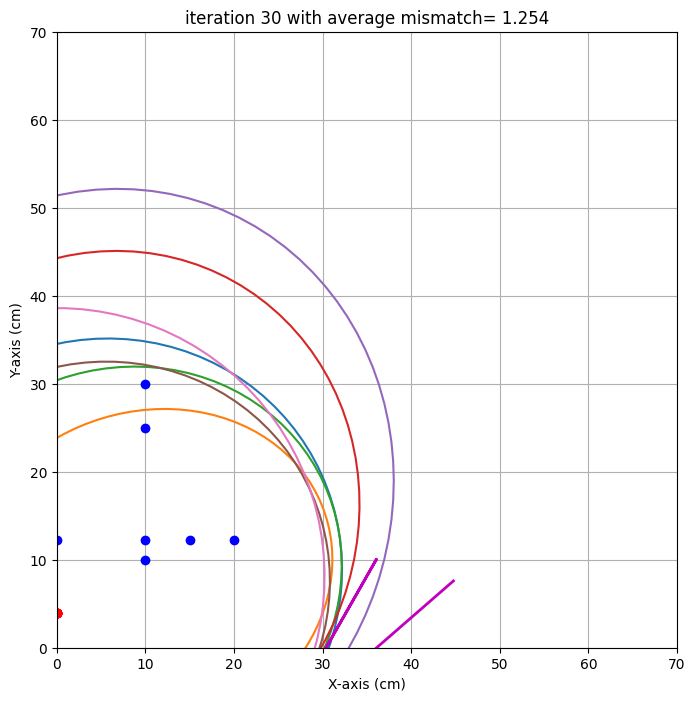

end iteration 30 with average mismatch= 1.254
###############################################################################
end of iteration  30
Best alpha=  41.22 with uncertainty=  13.21
Best beta =  29.51 with uncertainty=   7.54
Best x0   =  24.76 with uncertainty=   3.20
Best y0   =  -9.93 with uncertainty=   3.66
###############################################################################


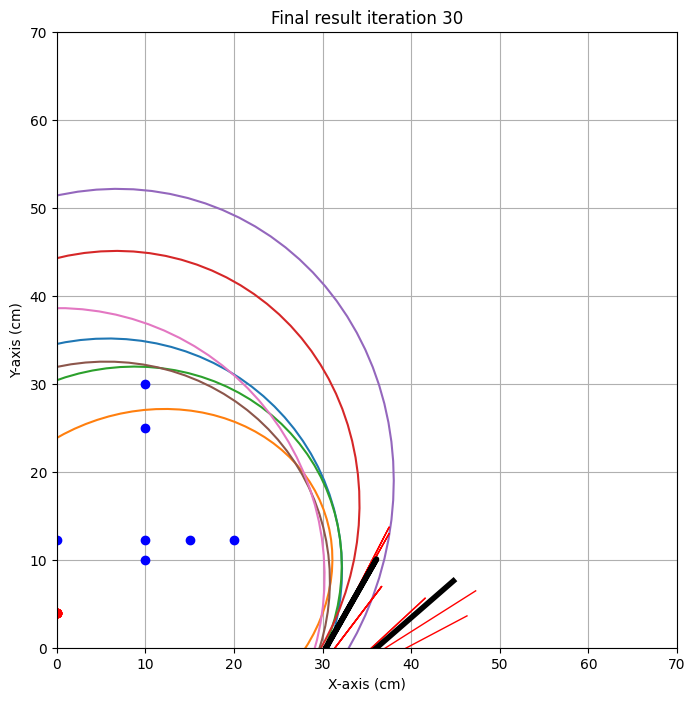

In [10]:
# xs, ys = vaste zender | xr, yr = losse ontvanger | R = waarde Serial Monitor
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0, 4, 10, 12.2, 55.0], # Meting 1
    [0, 4, 20, 12.2, 43.0], # Meting 2
    [0, 4, 15, 12.2, 50.0], # Meting 3
    [0, 4, 10, 25.0, 62.0], # Meting 4
    [0, 4, 10, 30.0, 71.0], # Meting 5
    [0, 4, 10, 10.0, 52.0], # Meting 6
    [0, 4, 0, 12.2, 61.0]   # Meting 7 (uit je vorige bericht)
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [11]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 24.8 cm met een standaardafwijking van 3.2 cm 
y0: -9.9 cm met een standaardafwijking van 3.7 cm 
alpha: 41.2 graden met een standaardafwijking van 13.2 graad 
beta: 29.5 graden met een standaardafwijking van 7.5 graad 



## Opdracht 5: Iteratie 0

#### algoritme [naam eerste student]
Voeg een foto in van het algoritme van het eerste groepslid
<img src="tudelftLogo.png" width="400">

#### algoritme [naam tweede student]
Voeg een foto in van het algoritme van het tweede groepslid
<img src="tudelftLogo.png" width="400">

#### algoritme [naam derde student]
Voeg een foto in van het algoritme van het derde groepslid
<img src="tudelftLogo.png" width="400">

In [ ]:
# Voeg hier eventueel code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 6: Test iteratie 0.

In [ ]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0':,  #zelf aanvullen,
           'y0':#zelf aanvullen,
           'alpha' : #zelf aanvullen,
           'beta' : #zelf aanvullen},
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'naam1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #zelf aanvullen
    ]),
       'naam2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #zelf aanvullen
    ]),
       'naam3' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #zelf aanvullen
    ])
      }

SyntaxError: expression expected after dictionary key and ':' (2248694369.py, line 4)

## Opdracht 7: Evaluatie.

In [ ]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

naam1


NameError: name 'data' is not defined

In [ ]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

NameError: name 'targets' is not defined

## Opdracht 8: Iteratie1+.VERVANG DEZE TEKST DOOR DE TIJD WANNEER JE AAN DEZE ITERATIE BEGINT.
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](tudelftLogo.png)


In [ ]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 9: Iteratie 1+ meeting en test

In [ ]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0':#zelf aanvullen,
                    'y0':#zelf aanvullen,
                    'alpha' : #zelf aanvullen,
                    'beta' : #zelf aanvullen},
           'locatie 2':{'x0':#zelf aanvullen,
                    'y0':#zelf aanvullen,
                    'alpha' : #zelf aanvullen,
                    'beta' : #zelf aanvullen}
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    # zelf aanvullen
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    # zelf aanvullen
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

SyntaxError: '{' was never closed (3018683157.py, line 4)

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

In [ ]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0':  # zelf aanvullen,
                    'y0':  # zelf aanvullen,
                    'alpha' :  # zelf aanvullen,
                    'beta' :  # zelf aanvullen
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                    # zelf aanvullen
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

SyntaxError: invalid syntax (598375666.py, line 7)

## Opdracht 11: Leerdoelen.
Figuur: ![Alt](tudelftLogo.png "Title")

Figuur: ![Alt](tudelftLogo.png "Title")

Figuur: ![Alt](tudelftLogo.png "Title")